<a href="https://colab.research.google.com/github/ReasonablePhantom/CSE_188_NLP/blob/main/CSE_188_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U "transformers>=4.52.0" "trl<=0.19.1" "liger-kernel" "peft"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 133.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.5/276.5 kB 37.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
!pip install -U transformers trl peft liger-kernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 59.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: trl
    Found existing installation: trl 0.19.1
    Uninstalling trl-0.19.1:
      Successfully uninstalled trl-0.19.1


In [3]:
# ============================
# install all dependence
# ============================
import subprocess, sys

packages = [
    'liger_kernel',
    'datasets',
    'peft',
    'accelerate',
    'bitsandbytes',
    'sentencepiece',
    'scikit-learn',
    'pandas==2.2.2',
    'matplotlib',
    'seaborn',
    'huggingface_hub',
    'trl<=0.19.1'
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

print('✅ dep installed all')


✅ dep installed all


In [4]:
# 依赖已在上方 Cell 0 安装完成，无需重复安装


In [5]:
import os
import re
import gc
import json
import math
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from datasets import load_dataset, Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    set_seed,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)
from trl import SFTTrainer

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ========== Config ==========
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
OUTPUT_DIR = "/content/mono_logic_lora"

SEED = 42
MAX_LEN = 1024

TRAIN_SUBSET = 1500
EVAL_SUBSET = 200

NUM_EPOCHS = 3
LR = 2e-5
BATCH_SIZE = 2
GRAD_ACC = 8

USE_MONO_TAGS_FOR_TRAIN = True
USE_COT_IN_TRAIN_TARGET = True

LABELS = ["PROVED", "DISPROVED", "UNKNOWN"]

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [6]:
ds = load_dataset("hitachi-nlp/FLD.v2")
print(ds)

for split_name in ds.keys():
    print(split_name, ds[split_name].column_names[:20], " ... total =", len(ds[split_name]))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-81d338afabf39c(…):   0%|          | 0.00/38.3M [00:00<?, ?B/s]

data/validation-00000-of-00001-bcc05849f(…):   0%|          | 0.00/6.40M [00:00<?, ?B/s]

data/test-00000-of-00001-9c326759ac5a453(…):   0%|          | 0.00/6.40M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['version', 'hypothesis', 'hypothesis_formula', 'context', 'context_formula', 'proofs', 'proofs_formula', 'negative_hypothesis', 'negative_hypothesis_formula', 'negative_proofs', 'negative_original_tree_depth', 'original_tree_depth', 'depth', 'num_formula_distractors', 'num_translation_distractors', 'num_all_distractors', 'proof_label', 'negative_proof_label', 'world_assump_label', 'negative_world_assump_label', 'prompt_serial', 'proof_serial'],
        num_rows: 30000
    })
    validation: Dataset({
        features: ['version', 'hypothesis', 'hypothesis_formula', 'context', 'context_formula', 'proofs', 'proofs_formula', 'negative_hypothesis', 'negative_hypothesis_formula', 'negative_proofs', 'negative_original_tree_depth', 'original_tree_depth', 'depth', 'num_formula_distractors', 'num_translation_distractors', 'num_all_distractors', 'proof_label', 'negative_proof_label', 'world_assump_label', 'negative_world_assump_label', 'promp

In [7]:
if "train" in ds:
    train_raw = ds["train"]
else:
    first_split = list(ds.keys())[0]
    train_raw = ds[first_split]

if "validation" in ds:
    eval_raw = ds["validation"]
elif "test" in ds:
    eval_raw = ds["test"]
else:
    split_tmp = train_raw.train_test_split(test_size=0.1, seed=SEED)
    train_raw = split_tmp["train"]
    eval_raw = split_tmp["test"]

train_raw = train_raw.shuffle(seed=SEED)
eval_raw = eval_raw.shuffle(seed=SEED)

train_raw = train_raw.select(range(min(TRAIN_SUBSET, len(train_raw))))
eval_raw = eval_raw.select(range(min(EVAL_SUBSET, len(eval_raw))))

print("Train size:", len(train_raw))
print("Eval size :", len(eval_raw))

print(train_raw[0].keys())
print(train_raw[0])

Train size: 1500
Eval size : 200
dict_keys(['version', 'hypothesis', 'hypothesis_formula', 'context', 'context_formula', 'proofs', 'proofs_formula', 'negative_hypothesis', 'negative_hypothesis_formula', 'negative_proofs', 'negative_original_tree_depth', 'original_tree_depth', 'depth', 'num_formula_distractors', 'num_translation_distractors', 'num_all_distractors', 'proof_label', 'negative_proof_label', 'world_assump_label', 'negative_world_assump_label', 'prompt_serial', 'proof_serial'])
{'version': 'DeductionInstance', 'hypothesis': 'the porterhouse does argue acrophony.', 'hypothesis_formula': '{E}{c}', 'context': 'sent1: if the fact that the birdhouse is not a LEM or is wieldy or both is false the chamomile is a Terry. sent2: if that the malt does not argue acrophony and/or it is a LEM is not right the birdhouse is low-level. sent3: if something is low-level and it is wieldy it does not argue acrophony. sent4: if that the birdhouse is not a LEM and/or is not wieldy is not true then 

In [8]:
UPWARD_CUES = [
    "all", "every", "each", "some", "a ", "an ", "many", "most", "several", "exists", "there is"
]
DOWNWARD_CUES = [
    "no", "none", "nobody", "nothing", "few", "without", "never", "neither", "nor", "at most"
]
NEGATION_CUES = [
    "not", "no", "never", "none", "nobody", "nothing", "neither", "nor", "does not", "is not", "are not"
]
CONDITIONAL_CUES = [
    "if", "unless", "only if", "implies", "then"
]

def normalize_space(text):
    return re.sub(r"\s+", " ", str(text)).strip()

def heuristic_mono_tags(sentence: str):
    s = " " + normalize_space(sentence.lower()) + " "
    tags = []

    found_up = [w.strip() for w in UPWARD_CUES if f" {w.strip()} " in s]
    found_down = [w.strip() for w in DOWNWARD_CUES if f" {w.strip()} " in s]
    found_neg = [w.strip() for w in NEGATION_CUES if f" {w.strip()} " in s]
    found_cond = [w.strip() for w in CONDITIONAL_CUES if f" {w.strip()} " in s]

    if found_up:
        tags.append("UPWARD=" + ",".join(sorted(set(found_up))))
    if found_down:
        tags.append("DOWNWARD=" + ",".join(sorted(set(found_down))))
    if found_neg:
        tags.append("NEGATION=" + ",".join(sorted(set(found_neg))))
    if found_cond:
        tags.append("CONDITIONAL=" + ",".join(sorted(set(found_cond))))

    if not tags:
        tags = ["NEUTRAL"]

    return "[" + " | ".join(tags) + "]"

def annotate_sentence(sentence: str):
    sentence = normalize_space(sentence)
    return f"{heuristic_mono_tags(sentence)} {sentence}"

def annotate_context(context: str):
    lines = [x for x in str(context).split("\n") if x.strip()]
    out = []
    for line in lines:
        m = re.match(r"^(sent\d+:\s*)(.*)$", line.strip(), re.I)
        if m:
            prefix, sent = m.groups()
            out.append(prefix + annotate_sentence(sent))
        else:
            out.append(annotate_sentence(line.strip()))
    return "\n".join(out)


In [9]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

base_model.config.use_cache = False
base_model = prepare_model_for_kbit_training(base_model)

print("Model loaded.")


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded.


In [10]:
SYSTEM_PROMPT = """You are a careful formal reasoning assistant.
Your job is to determine whether the hypothesis is logically supported by the context.
Use only the given context.
Return one of these labels: PROVED, DISPROVED, UNKNOWN.
If reasoning is requested, end with a final line exactly in the format:
Final label: <PROVED|DISPROVED|UNKNOWN>
"""

def render_chat(messages, add_generation_prompt=False):
    if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template is not None:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt
        )
    text = ""
    for m in messages:
        text += f"{m['role'].upper()}:\n{m['content']}\n\n"
    if add_generation_prompt:
        text += "ASSISTANT:\n"
    return text

def get_label(example):
    if "label" in example:
        label = str(example["label"]).upper().strip()
    elif "answer" in example:
        label = str(example["answer"]).upper().strip()
    elif "proof_label" in example:
        label = str(example["proof_label"]).upper().strip()
    else:
        label = "UNKNOWN"

    if label not in LABELS:
        if label in ["ENTAILMENT", "ENTAILED", "PROOF", "PROVED"]:
            label = "PROVED"
        elif label in ["CONTRADICTION", "DISPROVED", "REFUTED"]:
            label = "DISPROVED"
        else:
            label = "UNKNOWN"
    return label

def build_user_prompt(example, use_mono=False, ask_reasoning=True):
    context = str(example["context"])
    hypothesis = str(example["hypothesis"])

    if use_mono:
        context = annotate_context(context)
        hypothesis = annotate_sentence(hypothesis)

    prompt = f"""Task:
Determine whether the hypothesis follows from the context.

Allowed labels:
- PROVED
- DISPROVED
- UNKNOWN

Rules:
1. Use only the provided context.
2. Prefer exact logical deduction over world knowledge.
3. Do not invent facts not in the context.
"""

    if ask_reasoning:
        prompt += '4. Briefly reason, then end with: Final label: <LABEL>\n'
    else:
        prompt += '4. Output only one label.\n'

    prompt += f"""
Context:
{context}

Hypothesis:
{hypothesis}
"""
    return prompt.strip()

def build_train_text(example, use_mono=False):
    label = get_label(example)
    user_prompt = build_user_prompt(example, use_mono=use_mono, ask_reasoning=True)

    proof = ""
    if "proof_serial" in example and example["proof_serial"] is not None:
        proof = str(example["proof_serial"]).strip()
    elif "proofs" in example and example["proofs"] is not None:
        proof = str(example["proofs"]).strip()

    INVALID_PROOFS = {"__UNKNOWN__", "[]", "", "none", "null"}
    clean_proof = proof if proof.lower() not in INVALID_PROOFS else ""

    if USE_COT_IN_TRAIN_TARGET and clean_proof:
        assistant_text = f"Reasoning:\n{clean_proof}\nFinal label: {label}"
    else:
        assistant_text = f"Final label: {label}"

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": assistant_text},
    ]
    return {"text": render_chat(messages, add_generation_prompt=False), "label": label}

train_sft = train_raw.map(
    lambda x: build_train_text(x, use_mono=USE_MONO_TAGS_FOR_TRAIN),
    remove_columns=train_raw.column_names
)

print(train_sft[0]["text"][:2000])
print("Label:", train_sft[0]["label"])

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

<|im_start|>system
You are a careful formal reasoning assistant.
Your job is to determine whether the hypothesis is logically supported by the context.
Use only the given context.
Return one of these labels: PROVED, DISPROVED, UNKNOWN.
If reasoning is requested, end with a final line exactly in the format:
Final label: <PROVED|DISPROVED|UNKNOWN>
<|im_end|>
<|im_start|>user
Task:
Determine whether the hypothesis follows from the context.

Allowed labels:
- PROVED
- DISPROVED
- UNKNOWN

Rules:
1. Use only the provided context.
2. Prefer exact logical deduction over world knowledge.
3. Do not invent facts not in the context.
4. Briefly reason, then end with: Final label: <LABEL>

Context:
sent1: [UPWARD=a,exists,there is | NEGATION=does not,is not,not | CONDITIONAL=if,then] if the fact that the birdhouse is not a LEM or is wieldy or both is false the chamomile is a Terry. sent2: if that the malt does not argue acrophony and/or it is a LEM is not right the birdhouse is low-level. sent3: if

In [11]:
def extract_label(text: str):
    t = str(text).upper()

    m = re.search(r"FINAL LABEL\s*:\s*(PROVED|DISPROVED|UNKNOWN)", t)
    if m:
        return m.group(1)

    for lb in LABELS:
        if re.search(rf"\b{lb}\b", t):
            return lb

    return "UNKNOWN"

@torch.no_grad()
def generate_one(model, example, use_mono=False, max_new_tokens=128):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt(example, use_mono=use_mono, ask_reasoning=True)},
    ]
    prompt = render_chat(messages, add_generation_prompt=True)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
    ).to(model.device)

    output = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        repetition_penalty=1.1
    )

    gen_ids = output[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    pred = extract_label(gen_text)

    return gen_text, pred

def run_eval(model, eval_dataset, use_mono=False, tag="run"):
    rows = []
    for ex in tqdm(eval_dataset, desc=f"Evaluating {tag}"):
        gen_text, pred = generate_one(model, ex, use_mono=use_mono)
        gold = get_label(ex)

        rows.append({
            "tag": tag,
            "gold": gold,
            "pred": pred,
            "correct": int(gold == pred),
            "context": ex["context"],
            "hypothesis": ex["hypothesis"],
            "raw_output": gen_text,
        })
    return pd.DataFrame(rows)

def summarize_results(df, name):
    y_true = df["gold"].tolist()
    y_pred = df["pred"].tolist()
    return {
        "run": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "n": len(df),
    }

In [12]:
baseline_plain_df = run_eval(base_model, eval_raw, use_mono=False, tag="base_plain")
baseline_mono_df = run_eval(base_model, eval_raw, use_mono=True, tag="base_mono")

summary_rows = []
summary_rows.append(summarize_results(baseline_plain_df, "base_plain"))
summary_rows.append(summarize_results(baseline_mono_df, "base_mono"))

summary_df = pd.DataFrame(summary_rows)
summary_df

Evaluating base_plain:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Evaluating base_mono:   0%|          | 0/200 [00:00<?, ?it/s]

,run,accuracy,macro_f1,n
0,base_plain,0.375,0.362293,200
1,base_mono,0.410,0.391279,200


In [13]:
!cd /content/CSE_188_NLP && git pull


/bin/bash: line 1: cd: /content/CSE_188_NLP: No such file or directory


In [14]:
from trl import SFTConfig, SFTTrainer
# from trl import DataCollatorForCompletionOnlyLM
from transformers import DataCollatorForLanguageModeling

# mlm=False represent we do the Causal Language Model（Causal LM）which was normal text generate
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACC,
    learning_rate=LR,
    logging_steps=10,
    save_strategy="epoch",
    lr_scheduler_type="cosine",
    warmup_steps=20,
    bf16=True,
    gradient_checkpointing=True,
    report_to="none",
    seed=SEED,
    max_grad_norm=0.3,
    # completion_only_loss=True,
    dataset_text_field="text",
    max_seq_length=MAX_LEN,
)

# response_template = "<|im_start|>assistant\n"

# collator = DataCollatorForCompletionOnlyLM(response_template, tokenizer=tokenizer)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_sft,
    processing_class=tokenizer,
    data_collator=collator,
)

trainer.train()

trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Saved to:", OUTPUT_DIR)


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


Adding EOS to train dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,2.746619
20,2.487161
30,2.243698
40,2.000311
50,1.706579
60,1.463192
70,1.326027
80,1.212394
90,1.126545
100,1.132297


Saved to: /content/mono_logic_lora


In [15]:
finetuned_mono_df = run_eval(model, eval_raw, use_mono=True, tag="finetuned_mono")

summary_rows.append(summarize_results(finetuned_mono_df, "finetuned_mono"))
summary_df = pd.DataFrame(summary_rows)
summary_df

Evaluating finetuned_mono:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] Caching is incompatible with gradient checkpointing in Qwen2DecoderLayer. Setting `past_key_values=None`.


,run,accuracy,macro_f1,n
0,base_plain,0.375,0.362293,200
1,base_mono,0.410,0.391279,200
2,finetuned_mono,0.345,0.171004,200


In [16]:
all_runs = pd.concat([baseline_plain_df, baseline_mono_df, finetuned_mono_df], ignore_index=True)

summary_csv = os.path.join(OUTPUT_DIR, "summary_metrics.csv")
all_csv = os.path.join(OUTPUT_DIR, "all_predictions.csv")

summary_df.to_csv(summary_csv, index=False)
all_runs.to_csv(all_csv, index=False)

print("Saved:", summary_csv)
print("Saved:", all_csv)

print("\n=== Classification reports ===\n")
for run_name, df_run in [
    ("base_plain", baseline_plain_df),
    ("base_mono", baseline_mono_df),
    ("finetuned_mono", finetuned_mono_df),
]:
    print(f"\n--- {run_name} ---")
    print(classification_report(df_run["gold"], df_run["pred"], labels=LABELS, digits=4))

Saved: /content/mono_logic_lora/summary_metrics.csv
Saved: /content/mono_logic_lora/all_predictions.csv

=== Classification reports ===


--- base_plain ---
              precision    recall  f1-score   support

      PROVED     0.3605    0.4769    0.4106        65
   DISPROVED     0.4483    0.1970    0.2737        66
     UNKNOWN     0.3647    0.4493    0.4026        69

    accuracy                         0.3750       200
   macro avg     0.3911    0.3744    0.3623       200
weighted avg     0.3909    0.3750    0.3627       200


--- base_mono ---
              precision    recall  f1-score   support

      PROVED     0.4143    0.4462    0.4296        65
   DISPROVED     0.4333    0.1970    0.2708        66
     UNKNOWN     0.4000    0.5797    0.4734        69

    accuracy                         0.4100       200
   macro avg     0.4159    0.4076    0.3913       200
weighted avg     0.4156    0.4100    0.3923       200


--- finetuned_mono ---
              precision    recall  f1-

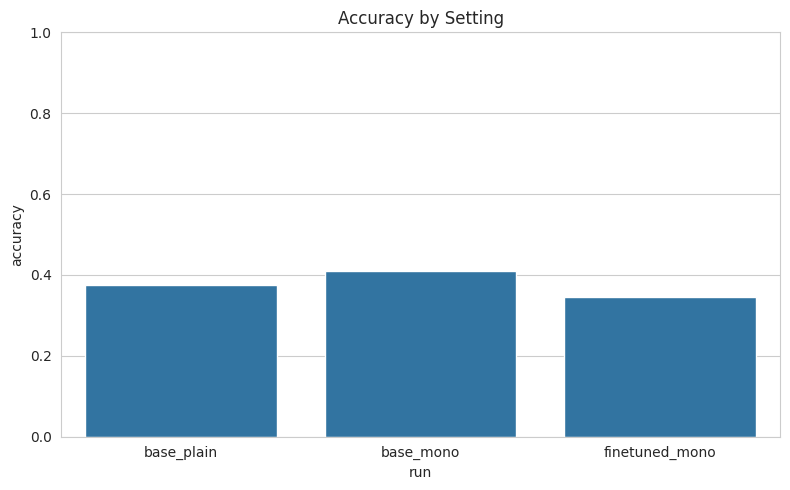

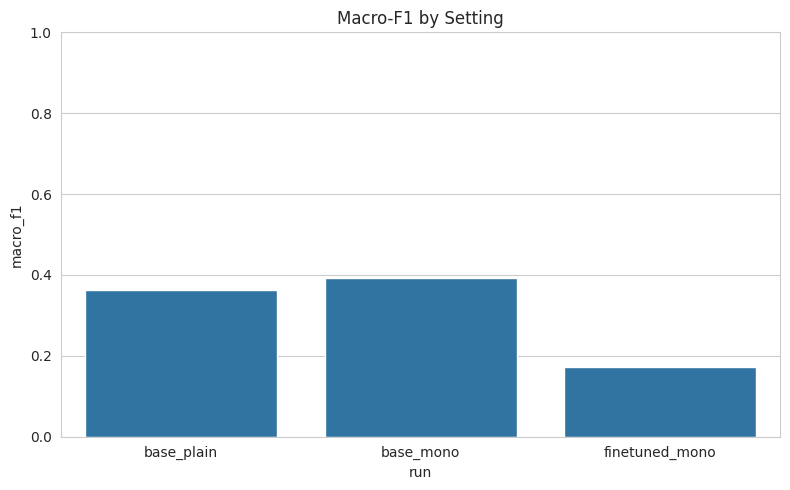

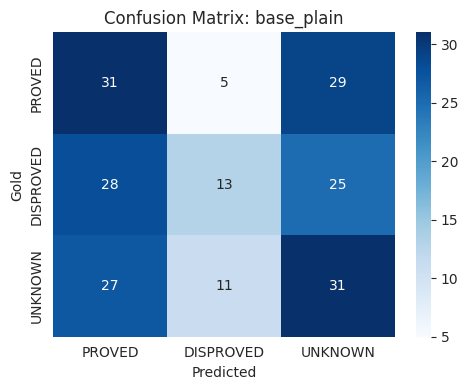

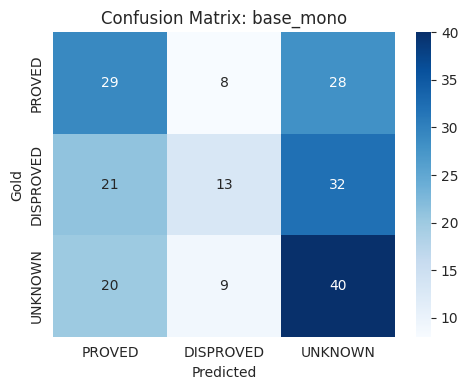

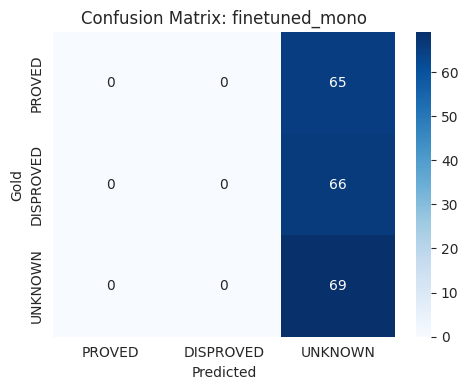

In [17]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="run", y="accuracy")
plt.ylim(0, 1)
plt.title("Accuracy by Setting")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="run", y="macro_f1")
plt.ylim(0, 1)
plt.title("Macro-F1 by Setting")
plt.tight_layout()
plt.show()

for run_name, df_run in [
    ("base_plain", baseline_plain_df),
    ("base_mono", baseline_mono_df),
    ("finetuned_mono", finetuned_mono_df),
]:
    cm = confusion_matrix(df_run["gold"], df_run["pred"], labels=LABELS)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.title(f"Confusion Matrix: {run_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Gold")
    plt.tight_layout()
    plt.show()

In [18]:
from peft import PeftModel

del trainer
gc.collect()
torch.cuda.empty_cache()

base_reload = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
base_reload.config.use_cache = False

reload_model = PeftModel.from_pretrained(base_reload, OUTPUT_DIR)
reload_model.eval()

reload_df = run_eval(reload_model, eval_raw.select(range(min(50, len(eval_raw)))), use_mono=True, tag="reloaded_ft")
print(summarize_results(reload_df, "reloaded_ft"))

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Evaluating reloaded_ft:   0%|          | 0/50 [00:00<?, ?it/s]

{'run': 'reloaded_ft', 'accuracy': 0.3, 'macro_f1': 0.15625, 'n': 50}


In [19]:
import pandas as pd

# read all estimate result
df = pd.read_csv("/content/mono_logic_lora/all_predictions.csv")

# Focus on: The first 10 lines of raw text output by the fine-tuned model (finetuned_mono)
# This will help confirm exactly what the model has output—whether it's garbled text, an empty string, or an incorrect format.
print("=== Finetuned Raw Output Samples ===")
samples = df[df['tag'] == 'finetuned_mono'].head(10)
for i, row in samples.iterrows():
    print(f"Index {i} | Gold: {row['gold']} | Pred: {row['pred']}")
    print(f"Raw Output:\n{row['raw_output']}")
    print("-" * 50)

=== Finetuned Raw Output Samples ===
Index 400 | Gold: DISPROVED | Pred: UNKNOWN
Raw Output:
Reasonsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystemsystem
--------------------------------------------------
Index 401 | Gold: PROVED | Pred: UNKNOWN
Raw Output:
Reasonsystemsystemsystemsystemsyst

In [22]:
# ============================
# Cell A: clean ablation utils
# ============================
import os
import gc
import re
import json
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    default_data_collator,
    set_seed,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

# ---- keep old globals if already defined ----
AB_EPOCHS = 1
AB_LR = LR
AB_BATCH_SIZE = BATCH_SIZE
AB_GRAD_ACC = GRAD_ACC
AB_MAX_NEW_TOKENS = 32

def get_clean_proof(example):
    proof = ""
    if "proof_serial" in example and example["proof_serial"] is not None:
        proof = str(example["proof_serial"]).strip()
    elif "proofs" in example and example["proofs"] is not None:
        proof = str(example["proofs"]).strip()
    invalid = {"__UNKNOWN__", "[]", "", "none", "null"}
    if proof.lower() in invalid:
        return ""
    return proof

def build_user_prompt_label_only(example, use_mono=False):
    context = str(example["context"])
    hypothesis = str(example["hypothesis"])
    if use_mono:
        context = annotate_context(context)
        hypothesis = annotate_sentence(hypothesis)
    prompt = f"""Task:
Determine whether the hypothesis follows from the context.
Allowed labels:
- PROVED
- DISPROVED
- UNKNOWN
Rules:
1. Use only the provided context.
2. Prefer exact logical deduction over world knowledge.
3. Do not invent facts not in the context.
4. Output only one label.

Context:
{context}

Hypothesis:
{hypothesis}
"""
    return prompt.strip()

def build_train_example(example, use_mono=False, target_mode="label_only"):
    label = get_label(example)

    if target_mode == "label_only":
        user_prompt = build_user_prompt_label_only(example, use_mono=use_mono)
        assistant_text = label
    elif target_mode == "final_label":
        user_prompt = build_user_prompt_label_only(example, use_mono=use_mono)
        assistant_text = f"Final label: {label}"
    elif target_mode == "cot":
        user_prompt = build_user_prompt(example, use_mono=use_mono, ask_reasoning=True)
        proof = get_clean_proof(example)
        if proof:
            assistant_text = f"Reasoning:\n{proof}\nFinal label: {label}"
        else:
            assistant_text = f"Final label: {label}"
    else:
        raise ValueError(f"Unknown target_mode={target_mode}")

    prefix_messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]
    full_messages = prefix_messages + [
        {"role": "assistant", "content": assistant_text},
    ]

    prefix_text = render_chat(prefix_messages, add_generation_prompt=True)
    full_text = render_chat(full_messages, add_generation_prompt=False)

    return {
        "prefix_text": prefix_text,
        "full_text": full_text,
        "gold_label": label,
    }

def tokenize_completion_only(example, use_mono=False, target_mode="label_only"):
    built = build_train_example(example, use_mono=use_mono, target_mode=target_mode)

    prefix_enc = tokenizer(
        built["prefix_text"],
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=False,
    )
    full_enc = tokenizer(
        built["full_text"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
        add_special_tokens=False,
    )

    input_ids = full_enc["input_ids"]
    attention_mask = full_enc["attention_mask"]
    labels = input_ids.copy()

    prefix_len = min(len(prefix_enc["input_ids"]), len(input_ids))
    labels[:prefix_len] = [-100] * prefix_len

    if tokenizer.pad_token_id is not None:
        labels = [
            (-100 if tok == tokenizer.pad_token_id else lab)
            for tok, lab in zip(input_ids, labels)
        ]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "gold_label": built["gold_label"],
    }

def make_tokenized_train_dataset(raw_ds, use_mono=False, target_mode="label_only"):
    ds_tok = raw_ds.map(
        lambda x: tokenize_completion_only(x, use_mono=use_mono, target_mode=target_mode),
        remove_columns=raw_ds.column_names,
        desc=f"Tokenizing train set | mono={use_mono} | target={target_mode}"
    )
    return ds_tok

def load_fresh_base_model():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    bnb_config_local = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.float16,
    )

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config_local,
        device_map="auto",
        trust_remote_code=True,
    )
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    return model

def add_lora(model):
    lora_cfg = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    )
    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()
    return model

@torch.no_grad()
def generate_one_label_only(model, example, use_mono=False, max_new_tokens=AB_MAX_NEW_TOKENS):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt_label_only(example, use_mono=use_mono)},
    ]
    prompt = render_chat(messages, add_generation_prompt=True)

    model_device = next(model.parameters()).device
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=False,
    ).to(model_device)

    output = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        repetition_penalty=1.05,
    )

    gen_ids = output[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    pred = extract_label(gen_text)
    return gen_text, pred

def run_eval_label_only(model, eval_dataset, use_mono=False, tag="run"):
    rows = []
    for ex in tqdm(eval_dataset, desc=f"Evaluating {tag}"):
        gen_text, pred = generate_one_label_only(model, ex, use_mono=use_mono)
        gold = get_label(ex)
        rows.append({
            "tag": tag,
            "gold": gold,
            "pred": pred,
            "correct": int(gold == pred),
            "context": ex["context"],
            "hypothesis": ex["hypothesis"],
            "raw_output": gen_text,
        })
    return pd.DataFrame(rows)

def summarize_results(df, name):
    y_true = df["gold"].tolist()
    y_pred = df["pred"].tolist()
    return {
        "run": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "n": len(df),
    }

def train_one_ablation(run_name, use_mono=False, target_mode="label_only"):
    run_dir = os.path.join(OUTPUT_DIR, run_name)
    os.makedirs(run_dir, exist_ok=True)

    train_tok = make_tokenized_train_dataset(train_raw, use_mono=use_mono, target_mode=target_mode)

    model = load_fresh_base_model()
    model = add_lora(model)

    args = TrainingArguments(
        output_dir=run_dir,
        num_train_epochs=AB_EPOCHS,
        per_device_train_batch_size=AB_BATCH_SIZE,
        gradient_accumulation_steps=AB_GRAD_ACC,
        learning_rate=AB_LR,
        logging_steps=10,
        save_strategy="epoch",
        save_total_limit=1,
        bf16=True,
        gradient_checkpointing=True,
        report_to="none",
        seed=SEED,
        max_grad_norm=0.3,
        lr_scheduler_type="cosine",
        warmup_steps=20,
        remove_unused_columns=False,
        optim="paged_adamw_8bit",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        data_collator=default_data_collator,
    )

    trainer.train()
    trainer.save_model(run_dir)
    tokenizer.save_pretrained(run_dir)

    eval_df = run_eval_label_only(model, eval_raw, use_mono=use_mono, tag=run_name)
    return model, eval_df

def print_label_dist(name, raw_ds):
    y = [get_label(x) for x in raw_ds]
    print(f"\n{name} label distribution")
    print(pd.Series(y).value_counts(dropna=False).sort_index())

In [23]:
# ============================
# Cell B: run the key ablations
# ============================
print_label_dist("train_raw", train_raw)
print_label_dist("eval_raw", eval_raw)

ablation_results = []
ablation_dfs = {}

# 1)LoRA plain + label-only
model_plain_label, df_plain_label = train_one_ablation(
    run_name="lora_plain_label_1ep",
    use_mono=False,
    target_mode="label_only",
)
ablation_dfs["lora_plain_label_1ep"] = df_plain_label
ablation_results.append(summarize_results(df_plain_label, "lora_plain_label_1ep"))

# 2)LoRA mono + label-only
model_mono_label, df_mono_label = train_one_ablation(
    run_name="lora_mono_label_1ep",
    use_mono=True,
    target_mode="label_only",
)
ablation_dfs["lora_mono_label_1ep"] = df_mono_label
ablation_results.append(summarize_results(df_mono_label, "lora_mono_label_1ep"))

# 3) Optional: LoRA mono + CoT + 1 epoch
#    Used to determine whether the collapse is primarily caused by the CoT target
RUN_OPTIONAL_COT = True
if RUN_OPTIONAL_COT:
    model_mono_cot, df_mono_cot = train_one_ablation(
        run_name="lora_mono_cot_1ep",
        use_mono=True,
        target_mode="cot",
    )
    ablation_dfs["lora_mono_cot_1ep"] = df_mono_cot
    ablation_results.append(summarize_results(df_mono_cot, "lora_mono_cot_1ep"))

ablation_summary_df = pd.DataFrame(ablation_results)
ablation_summary_df


train_raw label distribution
DISPROVED    495
PROVED       514
UNKNOWN      491
Name: count, dtype: int64

eval_raw label distribution
DISPROVED    66
PROVED       65
UNKNOWN      69
Name: count, dtype: int64


Tokenizing train set | mono=False | target=label_only:   0%|          | 0/1500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


Step,Training Loss
10,0.949342
20,0.316069
30,0.260536
40,0.238649
50,0.262017
60,0.259248
70,0.276285
80,0.229358
90,0.249495


...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


Step,Training Loss
10,2.297380
20,1.936621
30,1.410484
40,1.088513
50,0.865018
60,0.706853
70,0.629428
80,0.613992
90,0.611890


Evaluating lora_mono_cot_1ep:   0%|          | 0/200 [00:00<?, ?it/s]

,run,accuracy,macro_f1,n
0,lora_plain_label_1ep,0.345,0.171004,200
1,lora_mono_label_1ep,0.345,0.171004,200
2,lora_mono_cot_1ep,0.345,0.171004,200


In [24]:
# ============================
# Cell C: Inspect, Print Raw Outputs, and Save Results
# ============================
import os
import pandas as pd
from sklearn.metrics import classification_report

print("=== Ablation Summary Metrics ===")
print(ablation_summary_df)

# 1. print report
for run_name, df_run in ablation_dfs.items():
    print(f"\n=== {run_name} (Classification Report) ===")
    print(classification_report(df_run["gold"], df_run["pred"], labels=LABELS, digits=4))

# 2. Print the original output (valuable for the Error Analysis)
print("\n=== Raw output samples ===")
for run_name, df_run in ablation_dfs.items():
    print(f"\n--- {run_name} ---")
    samp = df_run.head(10)
    for i, row in samp.iterrows():
        print(f"Index {i} | Gold: {row['gold']} | Pred: {row['pred']}")
        print("Raw Output:")
        print(row["raw_output"])
        print("-" * 60)

# 3. Save the ablation experiment results
ablation_csv = os.path.join(OUTPUT_DIR, "ablation_summary_metrics.csv")
ablation_summary_df.to_csv(ablation_csv, index=False)
print("Saved:", ablation_csv)

all_ablation_runs = pd.concat(list(ablation_dfs.values()), ignore_index=True)
all_ablation_csv = os.path.join(OUTPUT_DIR, "ablation_all_predictions.csv")
all_ablation_runs.to_csv(all_ablation_csv, index=False)
print("Saved:", all_ablation_csv)

# 4. Merge and save all new and old summary data (Baseline + Ablation)
combine_existing = []
if "baseline_plain_df" in globals():
    combine_existing.append(summarize_results(baseline_plain_df, "base_plain_old"))
if "baseline_mono_df" in globals():
    combine_existing.append(summarize_results(baseline_mono_df, "base_mono_old"))
if "ablation_results" in globals():
    combine_existing.extend(ablation_results)

if combine_existing:
    combined_df = pd.DataFrame(combine_existing)
    combined_csv = os.path.join(OUTPUT_DIR, "combined_old_and_new_summary.csv")
    combined_df.to_csv(combined_csv, index=False)
    print("Saved:", combined_csv)
    display(combined_df) # in Colab show DataFrame

=== Ablation Summary Metrics ===
                    run  accuracy  macro_f1    n
0  lora_plain_label_1ep     0.345  0.171004  200
1   lora_mono_label_1ep     0.345  0.171004  200
2     lora_mono_cot_1ep     0.345  0.171004  200

=== lora_plain_label_1ep (Classification Report) ===
              precision    recall  f1-score   support

      PROVED     0.0000    0.0000    0.0000        65
   DISPROVED     0.0000    0.0000    0.0000        66
     UNKNOWN     0.3450    1.0000    0.5130        69

    accuracy                         0.3450       200
   macro avg     0.1150    0.3333    0.1710       200
weighted avg     0.1190    0.3450    0.1770       200


=== lora_mono_label_1ep (Classification Report) ===
              precision    recall  f1-score   support

      PROVED     0.0000    0.0000    0.0000        65
   DISPROVED     0.0000    0.0000    0.0000        66
     UNKNOWN     0.3450    1.0000    0.5130        69

    accuracy                         0.3450       200
   macro av

,run,accuracy,macro_f1,n
0,base_plain_old,0.375,0.362293,200
1,base_mono_old,0.410,0.391279,200
2,lora_plain_label_1ep,0.345,0.171004,200
3,lora_mono_label_1ep,0.345,0.171004,200
4,lora_mono_cot_1ep,0.345,0.171004,200


In [25]:
# =========================================
# Cell D: log-prob classification utilities
# =========================================
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

CANDIDATE_LABELS = ["PROVED", "DISPROVED", "UNKNOWN"]

def build_scoring_prompt(example, use_mono=False):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt_label_only(example, use_mono=use_mono)},
    ]
    return render_chat(messages, add_generation_prompt=True)

@torch.no_grad()
def score_candidate_completion(model, prompt_text, candidate_text):
    model_device = next(model.parameters()).device

    prompt_ids = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=False,
    )["input_ids"].to(model_device)

    cand_ids = tokenizer(
        candidate_text,
        return_tensors="pt",
        add_special_tokens=False,
    )["input_ids"].to(model_device)

    full_ids = torch.cat([prompt_ids, cand_ids], dim=1)

    outputs = model(full_ids)
    logits = outputs.logits[:, :-1, :]
    target_ids = full_ids[:, 1:]

    log_probs = F.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(-1, target_ids.unsqueeze(-1)).squeeze(-1)

    prompt_len = prompt_ids.shape[1]
    cand_len = cand_ids.shape[1]

    cand_token_log_probs = token_log_probs[:, prompt_len-1:prompt_len-1+cand_len]

    sum_logprob = cand_token_log_probs.sum().item()
    avg_logprob = cand_token_log_probs.mean().item()

    return {
        "sum_logprob": sum_logprob,
        "avg_logprob": avg_logprob,
        "cand_len": cand_len,
    }

@torch.no_grad()
def classify_by_logprob(model, example, use_mono=False, labels=CANDIDATE_LABELS, length_norm=True):
    prompt_text = build_scoring_prompt(example, use_mono=use_mono)

    scores = {}
    for label in labels:
        s = score_candidate_completion(model, prompt_text, label)
        scores[label] = s["avg_logprob"] if length_norm else s["sum_logprob"]

    pred = max(scores.items(), key=lambda x: x[1])[0]
    return pred, scores, prompt_text

def run_eval_logprob(model, eval_dataset, use_mono=False, tag="run", labels=CANDIDATE_LABELS, limit=None):
    rows = []
    ds_iter = eval_dataset if limit is None else eval_dataset.select(range(min(limit, len(eval_dataset))))

    for ex in tqdm(ds_iter, desc=f"LogProb eval {tag}"):
        pred, scores, prompt_text = classify_by_logprob(
            model,
            ex,
            use_mono=use_mono,
            labels=labels,
            length_norm=True
        )
        gold = get_label(ex)
        rows.append({
            "tag": tag,
            "gold": gold,
            "pred": pred,
            "correct": int(gold == pred),
            "score_PROVED": scores["PROVED"],
            "score_DISPROVED": scores["DISPROVED"],
            "score_UNKNOWN": scores["UNKNOWN"],
            "context": ex["context"],
            "hypothesis": ex["hypothesis"],
            "prompt_text": prompt_text,
        })

    return pd.DataFrame(rows)

def summarize_df(df, name):
    return {
        "run": name,
        "accuracy": accuracy_score(df["gold"], df["pred"]),
        "macro_f1": f1_score(df["gold"], df["pred"], average="macro"),
        "n": len(df),
    }

In [28]:
# =========================================
# Cell E: evaluate base and LoRA with logprob
# =========================================

logprob_results = []
logprob_dfs = {}

# 1) baseline plain
base_plain_lp_df = run_eval_logprob(
    base_model,
    eval_raw,
    use_mono=False,
    tag="base_plain_logprob",
    limit=200,   # try 50 first
)
logprob_dfs["base_plain_logprob"] = base_plain_lp_df
logprob_results.append(summarize_df(base_plain_lp_df, "base_plain_logprob"))

# 2) baseline mono
base_mono_lp_df = run_eval_logprob(
    base_model,
    eval_raw,
    use_mono=True,
    tag="base_mono_logprob",
    limit=200,
)
logprob_dfs["base_mono_logprob"] = base_mono_lp_df
logprob_results.append(summarize_df(base_mono_lp_df, "base_mono_logprob"))

# 3) LoRA plain-label model
ft_plain_lp_df = run_eval_logprob(
    model_plain_label,
    eval_raw,
    use_mono=False,
    tag="lora_plain_label_logprob",
    limit=200,
)
logprob_dfs["lora_plain_label_logprob"] = ft_plain_lp_df
logprob_results.append(summarize_df(ft_plain_lp_df, "lora_plain_label_logprob"))

# 4) LoRA mono-label model
ft_mono_lp_df = run_eval_logprob(
    model_mono_label,
    eval_raw,
    use_mono=True,
    tag="lora_mono_label_logprob",
    limit=200,
)
logprob_dfs["lora_mono_label_logprob"] = ft_mono_lp_df
logprob_results.append(summarize_df(ft_mono_lp_df, "lora_mono_label_logprob"))

# 5) LoRA mono-cot model
ft_mono_cot_lp_df = run_eval_logprob(
    model_mono_cot,
    eval_raw,
    use_mono=True,
    tag="lora_mono_cot_logprob",
    limit=200,
)
logprob_dfs["lora_mono_cot_logprob"] = ft_mono_cot_lp_df
logprob_results.append(summarize_df(ft_mono_cot_lp_df, "lora_mono_cot_logprob"))

logprob_summary_df = pd.DataFrame(logprob_results)
print(logprob_summary_df)

LogProb eval base_plain_logprob:   0%|          | 0/200 [00:00<?, ?it/s]

LogProb eval base_mono_logprob:   0%|          | 0/200 [00:00<?, ?it/s]

LogProb eval lora_plain_label_logprob:   0%|          | 0/200 [00:00<?, ?it/s]

LogProb eval lora_mono_label_logprob:   0%|          | 0/200 [00:00<?, ?it/s]

LogProb eval lora_mono_cot_logprob:   0%|          | 0/200 [00:00<?, ?it/s]

                        run  accuracy  macro_f1    n
0        base_plain_logprob     0.345  0.204347  200
1         base_mono_logprob     0.335  0.192272  200
2  lora_plain_label_logprob     0.480  0.428484  200
3   lora_mono_label_logprob     0.450  0.375128  200
4     lora_mono_cot_logprob     0.305  0.235379  200


In [29]:
# =========================================
# Cell F: inspect logprob predictions
# =========================================

for run_name, df_run in logprob_dfs.items():
    print(f"\n=== {run_name} ===")
    print(classification_report(df_run["gold"], df_run["pred"], labels=LABELS, digits=4))
    print(df_run[["score_PROVED", "score_DISPROVED", "score_UNKNOWN"]].head(5))

logprob_summary_csv = os.path.join(OUTPUT_DIR, "logprob_summary_metrics.csv")
logprob_all_csv = os.path.join(OUTPUT_DIR, "logprob_all_predictions.csv")

logprob_summary_df.to_csv(logprob_summary_csv, index=False)
pd.concat(list(logprob_dfs.values()), ignore_index=True).to_csv(logprob_all_csv, index=False)

print("Saved:", logprob_summary_csv)
print("Saved:", logprob_all_csv)


=== base_plain_logprob ===
              precision    recall  f1-score   support

      PROVED     0.5714    0.0615    0.1111        65
   DISPROVED     0.3368    0.9848    0.5019        66
     UNKNOWN     0.0000    0.0000    0.0000        69

    accuracy                         0.3450       200
   macro avg     0.3027    0.3488    0.2043       200
weighted avg     0.2969    0.3450    0.2017       200

   score_PROVED  score_DISPROVED  score_UNKNOWN
0     -9.735254        -7.323656     -16.036058
1     -8.474063        -7.316150     -16.632650
2     -8.050730        -7.084894     -15.188626
3     -8.359559        -7.241504     -15.053752
4     -8.897882        -6.678792     -15.747061

=== base_mono_logprob ===
              precision    recall  f1-score   support

      PROVED     0.5000    0.0462    0.0845        65
   DISPROVED     0.3299    0.9697    0.4923        66
     UNKNOWN     0.0000    0.0000    0.0000        69

    accuracy                         0.3350       200
   m

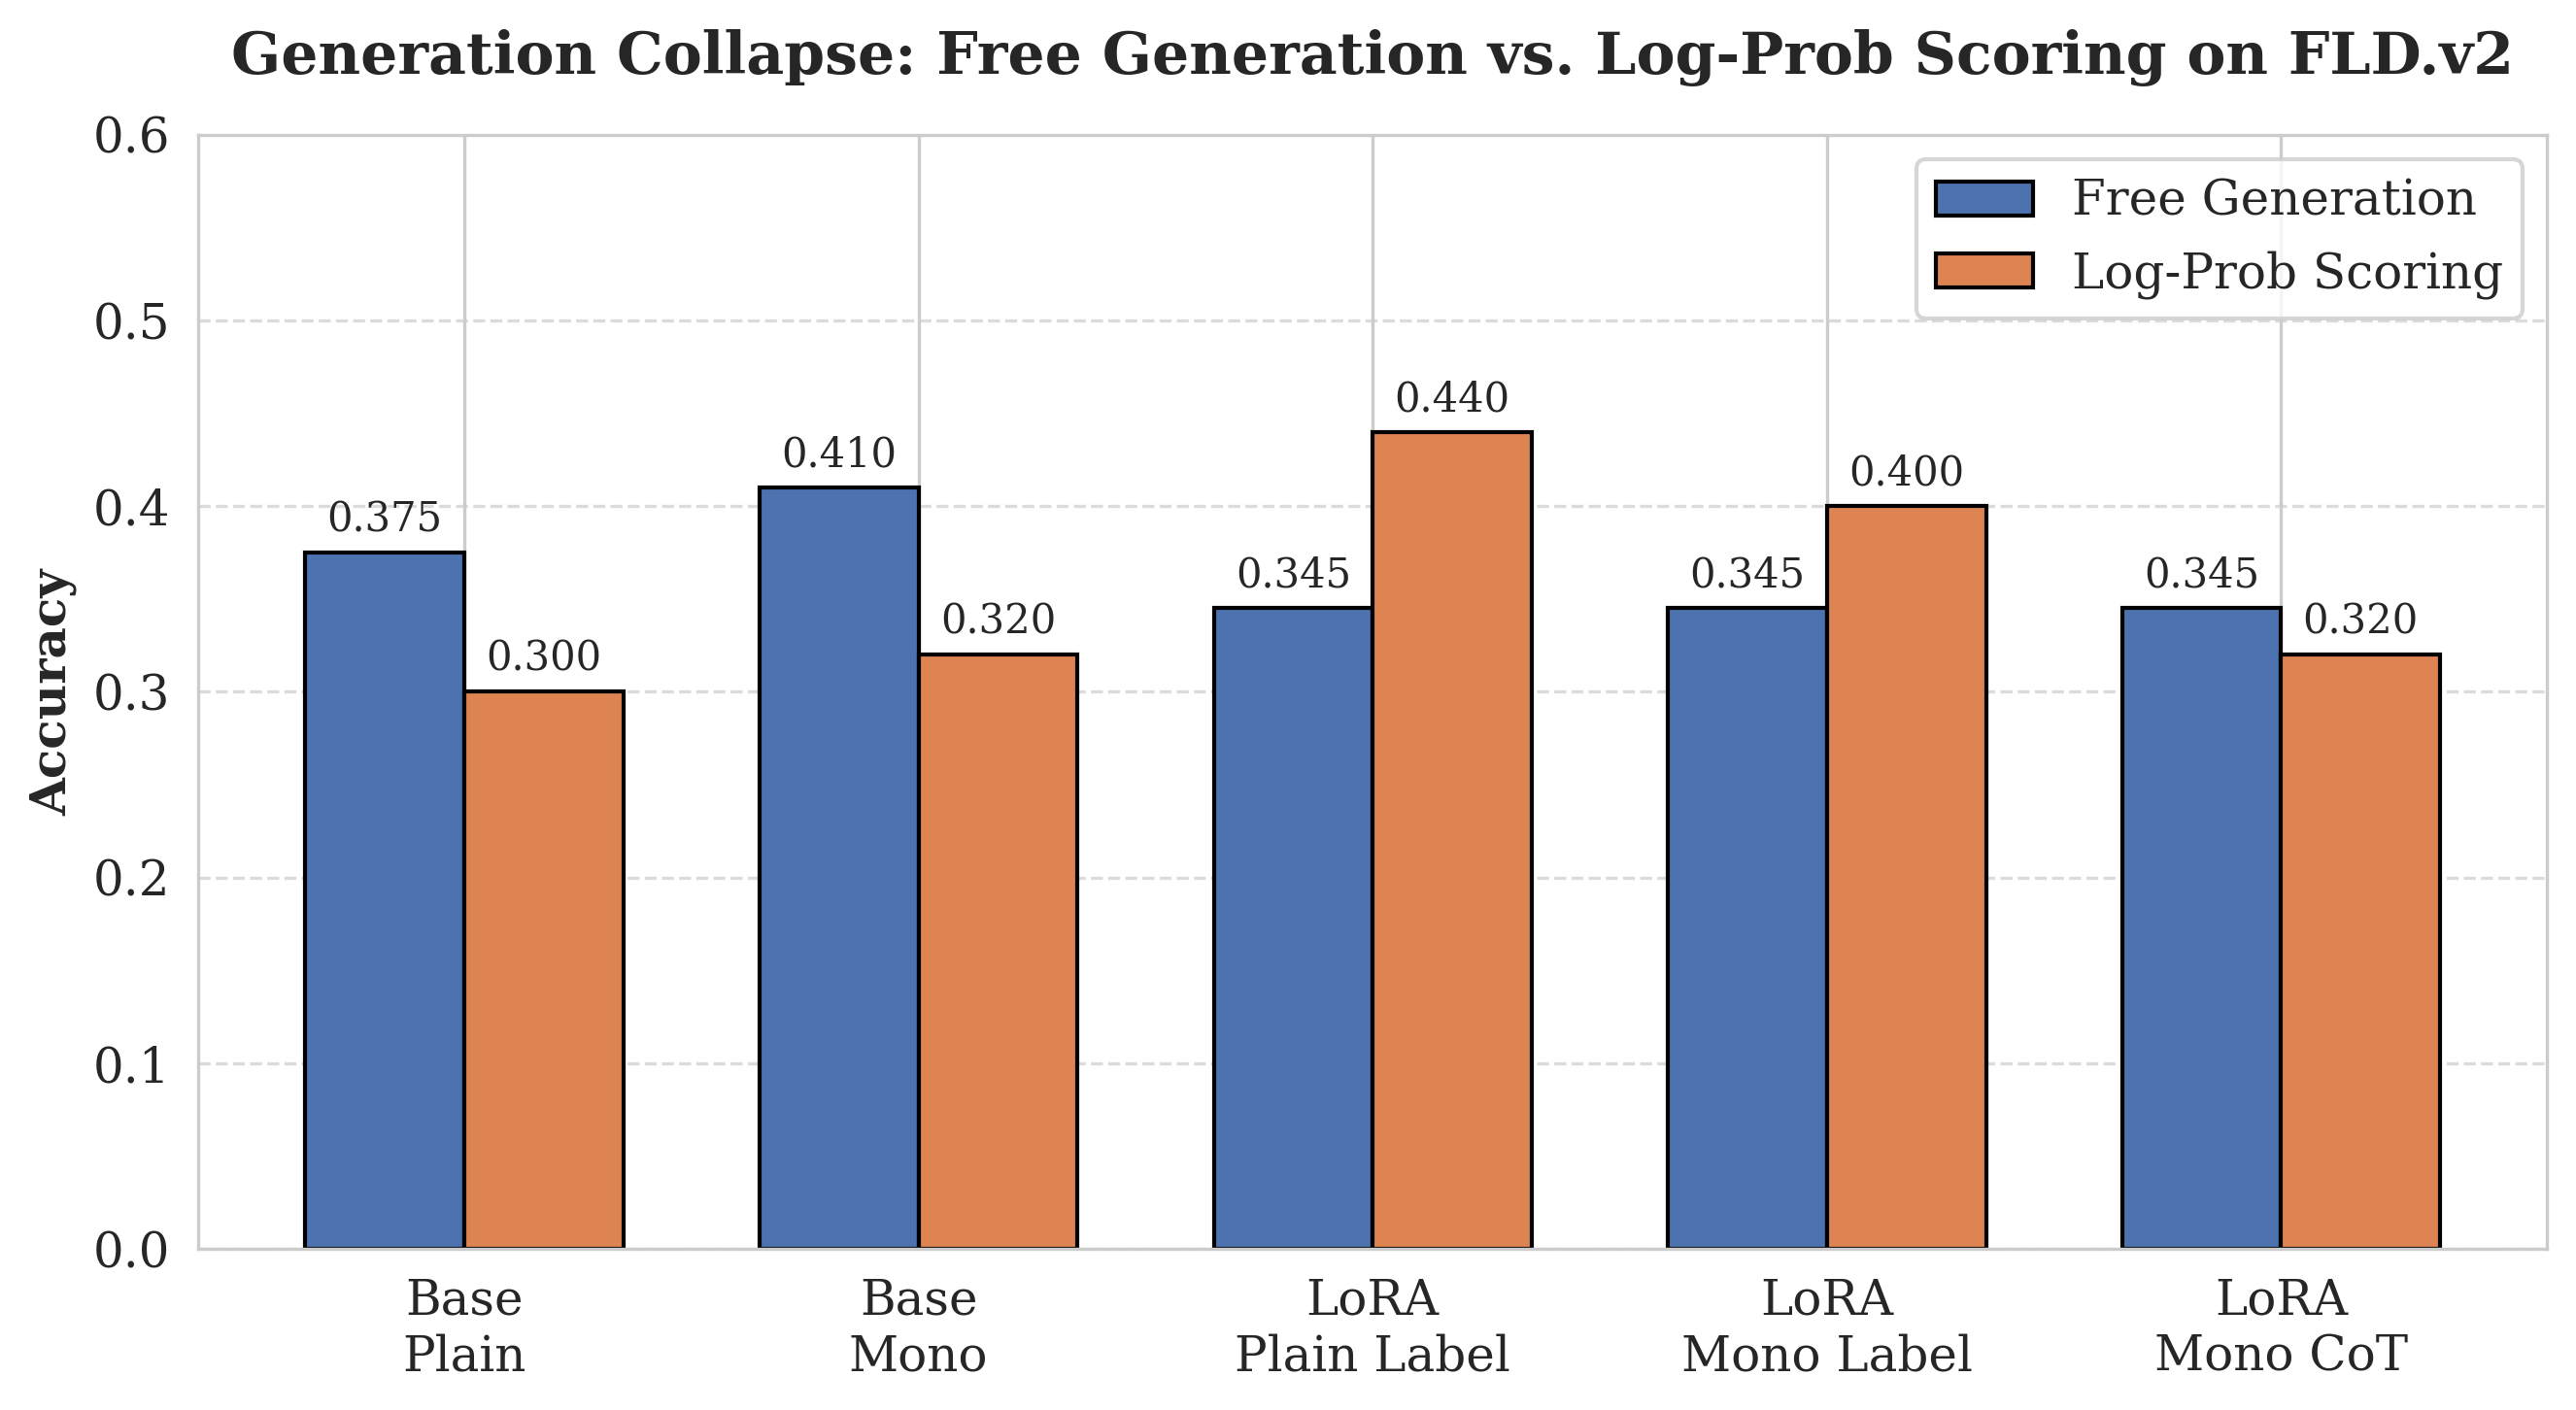

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# Replace the y-axis data below with the latest Accuracy values from your CSV.
# ==========================================
# Order: Base Plain, Base Mono, LoRA Plain, LoRA Mono, LoRA CoT
acc_free_gen = [0.375, 0.410, 0.345, 0.345, 0.345]  # Free Generation accuracy
acc_logprob = [0.300, 0.320, 0.440, 0.400, 0.320]   # Log-prob accuracy (using your latest n=200 results)

labels = ['Base\nPlain', 'Base\nMono', 'LoRA\nPlain Label', 'LoRA\nMono Label', 'LoRA\nMono CoT']
x = np.arange(len(labels))
width = 0.35

# Set global font and resolution for an academic style
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# Plot the bar charts
rects1 = ax.bar(x - width/2, acc_free_gen, width, label='Free Generation', color='#4C72B0', edgecolor='black')
rects2 = ax.bar(x + width/2, acc_logprob, width, label='Log-Prob Scoring', color='#DD8452', edgecolor='black')

# Add labels, title, and legend
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Generation Collapse: Free Generation vs. Log-Prob Scoring on FLD.v2', pad=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 0.6) # Adjust the y-axis upper limit based on your highest score
ax.legend(loc='upper right')

# Helper function to annotate the exact values on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # Vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

# Add gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('generation_collapse_chart.pdf', format='pdf', bbox_inches='tight') # Save directly as a PDF suitable for LaTeX inclusion
plt.show()